# Fly connectome exploration
Notebook to explore the fly connectome dataset (`connections_princeton.csv`, `labels.csv`, `names.csv`). It loads the data, inspects structure, and builds visualizations (distributions, top nodes, network views).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
import json

# Optional interactive plotly (fallback to matplotlib if unavailable)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except Exception:
    HAS_PLOTLY = False

sns.set_context('talk')
sns.set_style('whitegrid')
pd.options.display.max_columns = 50
plt.rcParams['figure.figsize'] = (10, 6)

print('Plotly available:' , HAS_PLOTLY)


Plotly available: True


In [2]:
DATA_DIR = Path('../data/raw')
CONNECTIONS_PATH = DATA_DIR / 'connections_princeton.csv'
LABELS_PATH = DATA_DIR / 'labels.csv'
NAMES_PATH = DATA_DIR / 'names.csv'

assert CONNECTIONS_PATH.exists(), 'connections_princeton.csv missing'
assert LABELS_PATH.exists(), 'labels.csv missing'
assert NAMES_PATH.exists(), 'names.csv missing'
DATA_DIR


PosixPath('../data/raw')

In [3]:
connections = pd.read_csv(CONNECTIONS_PATH)
labels = pd.read_csv(LABELS_PATH)
names = pd.read_csv(NAMES_PATH)

connections.head()


,pre_root_id,post_root_id,neuropil,syn_count,nt_type
0,720575940625363947,720575940623224444,ME_L,12,GABA
1,720575940630432382,720575940618518557,ME_L,67,ACH
2,720575940627314521,720575940626337738,ME_L,10,GABA
3,720575940620280405,720575940620204726,ME_L,15,ACH
4,720575940636942447,720575940613789411,LA_L,1,GLUT


## Basic dataset overview

In [4]:
print('Connections shape:', connections.shape)
print('Labels shape:', labels.shape)
print('Names shape:', names.shape)

display(connections.describe(include='all').T)


Connections shape: (5342446, 5)
Labels shape: (160045, 9)
Names shape: (139255, 3)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pre_root_id,5342446.0,NaN,NaN,NaN,720575940625212928.0,10018771.78646,720575940596125824.0,720575940618274432.0,720575940624991488.0,720575940631283456.0,720575940661339776.0
post_root_id,5342446.0,NaN,NaN,NaN,720575940625278080.0,9990511.72369,720575940596125824.0,720575940618362240.0,720575940625019904.0,720575940631311616.0,720575940661338496.0
neuropil,5342446,79,ME_R,660198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
syn_count,5342446.0,NaN,NaN,NaN,9.483792,14.776421,1.0,4.0,6.0,10.0,2633.0
nt_type,5342446,6,ACH,3210049,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Parse timestamps and keep the most recent label per neuron
labels['date_created'] = pd.to_datetime(labels['date_created'], errors='coerce')
latest_labels = labels.sort_values('date_created').groupby('root_id').tail(1)

# Consolidate name + label lookup
name_lookup = names.drop_duplicates('root_id').set_index('root_id')
label_lookup = latest_labels.set_index('root_id')[['label', 'user_name', 'user_affiliation', 'date_created']]
nodes = name_lookup.join(label_lookup, how='outer')
nodes.rename(columns={'name': 'flywire_name'}, inplace=True)
nodes.head()


,flywire_name,group,label,user_name,user_affiliation,date_created
root_id,,,,,,
720575940596125868,LO.LOP.561,LO.LOP,T5c; FBbt_00003739,Krzysztof Kruk,Eyewire,2023-05-10 22:26:35
720575940597856265,ME.2982,ME,Tm16; Transmedullary neuron 16; FBbt_00003804,Krzysztof Kruk,Eyewire,2023-05-17 18:05:34
720575940597944841,ME.LO.7713,ME.LO,Tm7; Transmedullary neuron 7; FBbt_00003795,Krzysztof Kruk,Eyewire,2023-05-23 13:07:33
720575940598267657,ME.4244,ME,TmY15; Transmedullary Y neuron 15; FBbt_00048246,Krzysztof Kruk,Eyewire,2023-03-30 16:46:34
720575940599333574,ME.5182,ME,Tm1; Transmedullary neuron 1; FBbt_00003789,Krzysztof Kruk,Eyewire,2023-07-19 21:15:05


In [6]:
syn_by_edge = connections['syn_count']
print('Total edges:', len(connections))
print('Unique presynaptic neurons:', connections['pre_root_id'].nunique())
print('Unique postsynaptic neurons:', connections['post_root_id'].nunique())
print('Total synapses (sum of syn_count):', syn_by_edge.sum())

syn_stats = syn_by_edge.describe(percentiles=[0.5, 0.9, 0.99])
syn_stats


Total edges: 5342446
Unique presynaptic neurons: 137518
Unique postsynaptic neurons: 130183
Total synapses (sum of syn_count): 50666648


count    5.342446e+06
mean     9.483792e+00
std      1.477642e+01
min      1.000000e+00
50%      6.000000e+00
90%      1.900000e+01
99%      6.300000e+01
max      2.633000e+03
Name: syn_count, dtype: float64

## Distributions

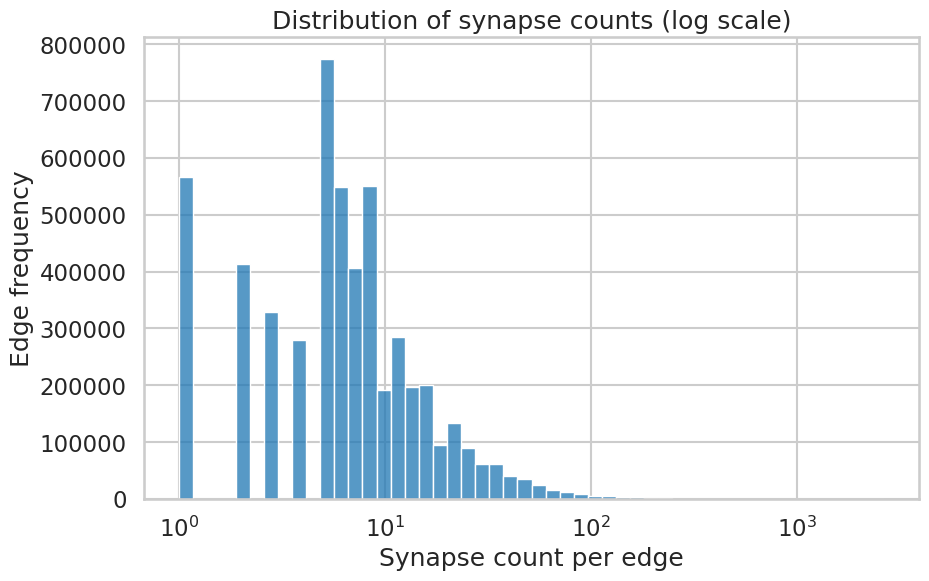

In [7]:
fig, ax = plt.subplots()
sns.histplot(syn_by_edge, bins=50, log_scale=True, ax=ax)
ax.set_xlabel('Synapse count per edge')
ax.set_ylabel('Edge frequency')
ax.set_title('Distribution of synapse counts (log scale)');
plt.show()


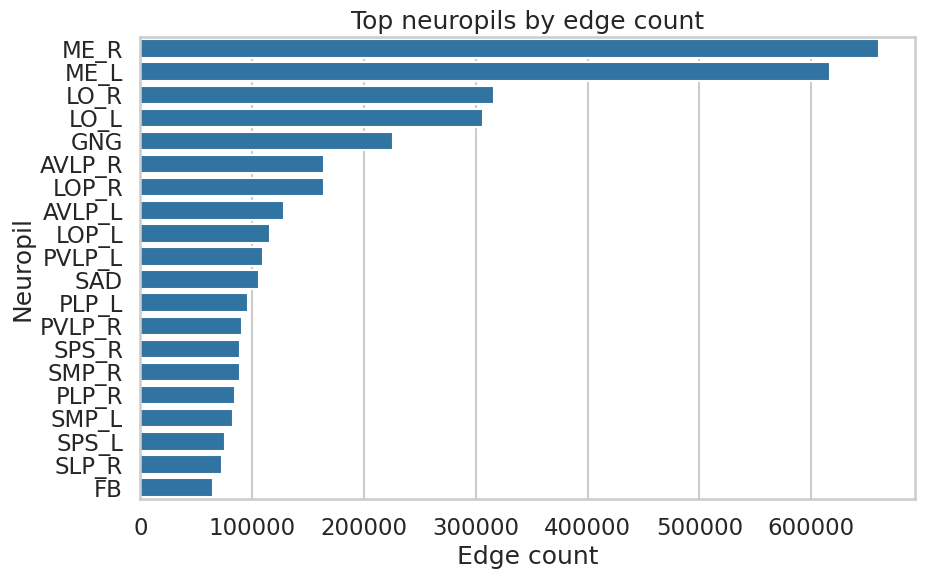

In [8]:
neuropil_counts = connections['neuropil'].value_counts().head(20)
fig, ax = plt.subplots()
sns.barplot(x=neuropil_counts.values, y=neuropil_counts.index, ax=ax)
ax.set_xlabel('Edge count')
ax.set_ylabel('Neuropil')
ax.set_title('Top neuropils by edge count');
plt.show()


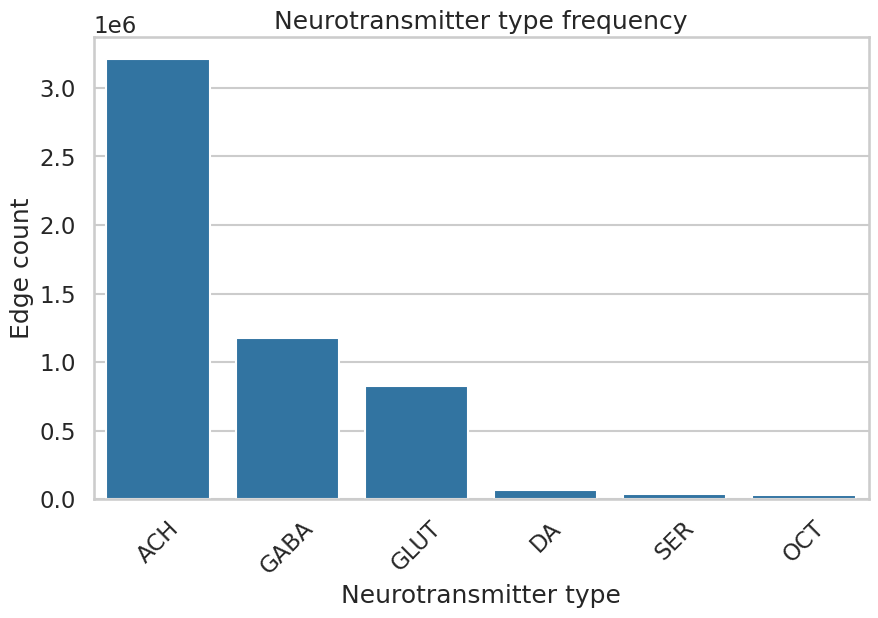

In [9]:
nt_counts = connections['nt_type'].value_counts(dropna=False)
fig, ax = plt.subplots()
sns.barplot(x=nt_counts.index, y=nt_counts.values, ax=ax)
ax.set_ylabel('Edge count')
ax.set_xlabel('Neurotransmitter type')
ax.set_title('Neurotransmitter type frequency')
ax.tick_params(axis='x', rotation=45)
plt.show()


## Node-level strength

In [10]:
pre_strength = connections.groupby('pre_root_id')['syn_count'].sum().sort_values(ascending=False)
post_strength = connections.groupby('post_root_id')['syn_count'].sum().sort_values(ascending=False)

def attach_labels(series):
    df = series.to_frame(name='synapses')
    df['flywire_name'] = nodes.reindex(df.index)['flywire_name']
    df['label'] = nodes.reindex(df.index)['label']
    return df

top_pre = attach_labels(pre_strength).head(15)
top_post = attach_labels(post_strength).head(15)
top_pre


,synapses,flywire_name,label
pre_root_id,,,
720575940626979621,110708,LO.1,CT1
720575940628908548,109699,LO.5422,CT1
720575940624547622,85998,MB_ML.1,APL-RHS
720575940613583001,74963,MB_ML.MB_CA.1,Mushroom Body
720575940625952755,46159,LO.3,NaN
720575940627497244,45647,LO.4,Li_unknown_3
720575940620008758,40215,LOP.1,#temp_NewType Lobula Plate Intrinsic 105_4-34;...
720575940634612194,39297,LOP.3,Lobula Plate intrinsic neuron 2-1f; LPi2-1f
720575940619991862,31254,LOP.6,NaN


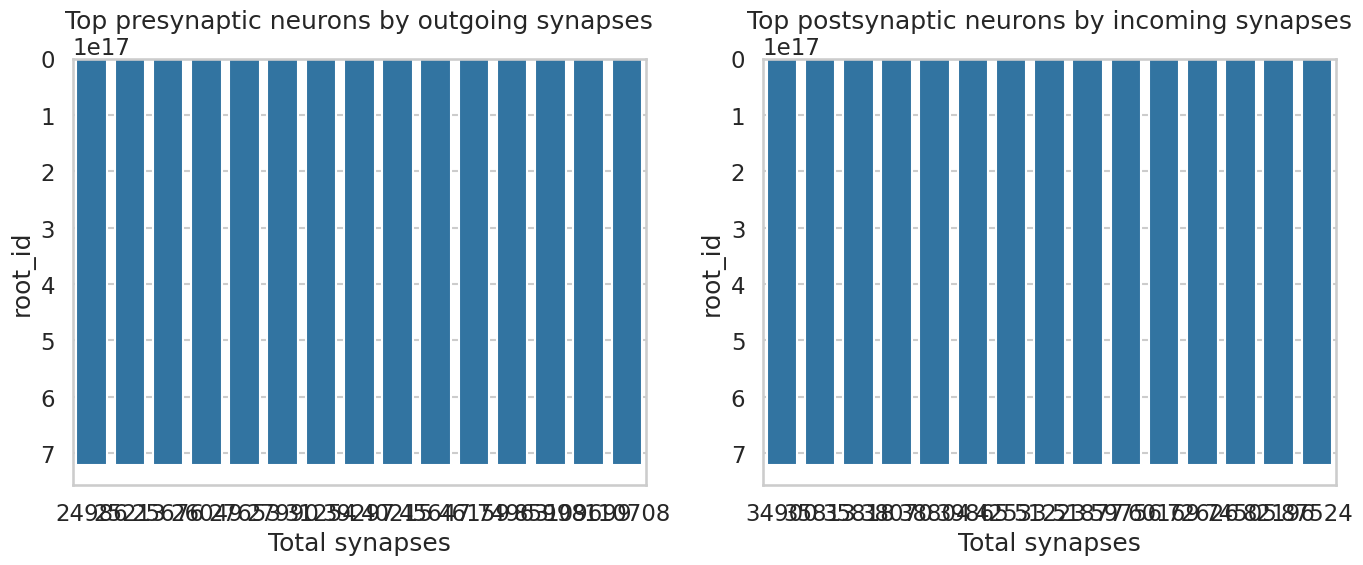

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)
sns.barplot(y=top_pre.index, x=top_pre['synapses'], ax=axes[0])
axes[0].set_title('Top presynaptic neurons by outgoing synapses')
axes[0].set_ylabel('root_id')
axes[0].set_xlabel('Total synapses')
axes[0].invert_yaxis()

sns.barplot(y=top_post.index, x=top_post['synapses'], ax=axes[1])
axes[1].set_title('Top postsynaptic neurons by incoming synapses')
axes[1].set_ylabel('root_id')
axes[1].set_xlabel('Total synapses')
axes[1].invert_yaxis()

plt.tight_layout();
plt.show()


## Graph construction and centrality

In [12]:
G = nx.from_pandas_edgelist(
    connections,
    source='pre_root_id',
    target='post_root_id',
    edge_attr=['syn_count', 'neuropil', 'nt_type'],
    create_using=nx.DiGraph()
)

# networkx>=3 removed nx.info, so summarize manually
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
dens = nx.density(G)
print(f"Directed graph with {n_nodes:,} nodes and {n_edges:,} edges; density={dens:.4e}")


Directed graph with 138,584 nodes and 3,732,460 edges; density=1.9434e-04


In [13]:
degree_df = pd.DataFrame({
    'out_degree': dict(G.out_degree()),
    'in_degree': dict(G.in_degree()),
    'out_strength': dict(G.out_degree(weight='syn_count')) ,
    'in_strength': dict(G.in_degree(weight='syn_count'))
})

degree_df['flywire_name'] = nodes.reindex(degree_df.index)['flywire_name']
degree_df['label'] = nodes.reindex(degree_df.index)['label']
degree_df.sort_values('out_strength', ascending=False).head(10)


,out_degree,in_degree,out_strength,in_strength,flywire_name,label
720575940626979621,6523,6261,109608,72003,LO.1,CT1
720575940628908548,6447,5997,108485,69833,LO.5422,CT1
720575940625952755,2504,2183,45810,38362,LO.3,NaN
720575940627497244,2378,2138,45082,37233,LO.4,Li_unknown_3
720575940620008758,2443,1986,40208,31295,LOP.1,#temp_NewType Lobula Plate Intrinsic 105_4-34;...
720575940634612194,1394,1936,39264,60138,LOP.3,Lobula Plate intrinsic neuron 2-1f; LPi2-1f
720575940619991862,1243,1832,31254,51221,LOP.6,NaN
720575940611563310,1374,1317,27873,24483,ME.39072,Mti_unknown_7
720575940612976497,1824,210,25652,1732,GNG.ME.1,pMP7
720575940629382150,1967,1353,24542,16851,LOP.5,Lobula Plate intrinsic neuron 2b; LPi2b; https...


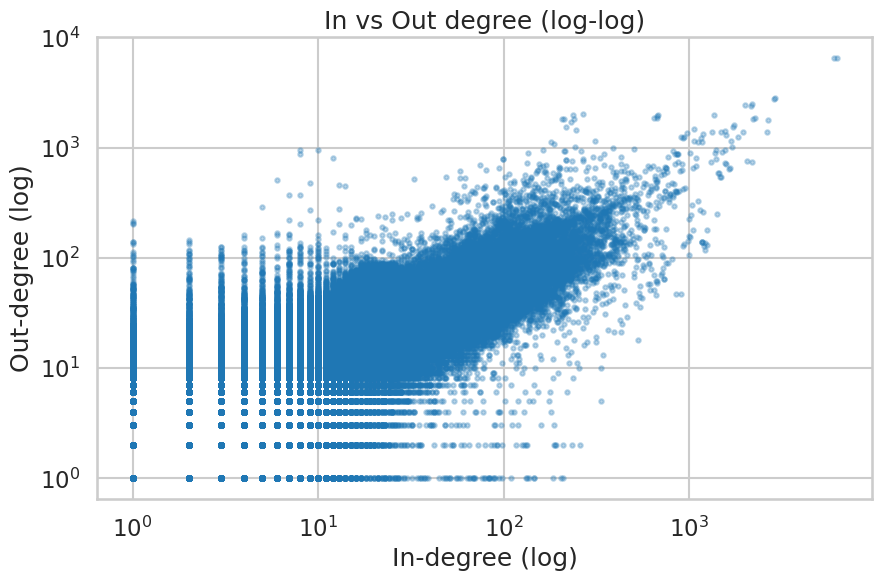

In [14]:
fig, ax = plt.subplots()
ax.scatter(degree_df['in_degree'], degree_df['out_degree'], alpha=0.3, s=10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('In-degree (log)')
ax.set_ylabel('Out-degree (log)')
ax.set_title('In vs Out degree (log-log)');
plt.show()


## Mesoscale patterns

In [15]:
print("top_nodes  :", degree_df.sort_values('out_strength', ascending=False).head(30).index)

top_nodes  : Index([720575940626979621, 720575940628908548, 720575940625952755,
       720575940627497244, 720575940620008758, 720575940634612194,
       720575940619991862, 720575940611563310, 720575940612976497,
       720575940629382150, 720575940623444044, 720575940650935673,
       720575940631945815, 720575940618308825, 720575940628069501,
       720575940622523508, 720575940609282825, 720575940622726271,
       720575940630770042, 720575940632795532, 720575940627190556,
       720575940632504874, 720575940634545890, 720575940640851363,
       720575940604569824, 720575940640736371, 720575940640834211,
       720575940623000858, 720575940618366843, 720575940637689486],
      dtype='int64')


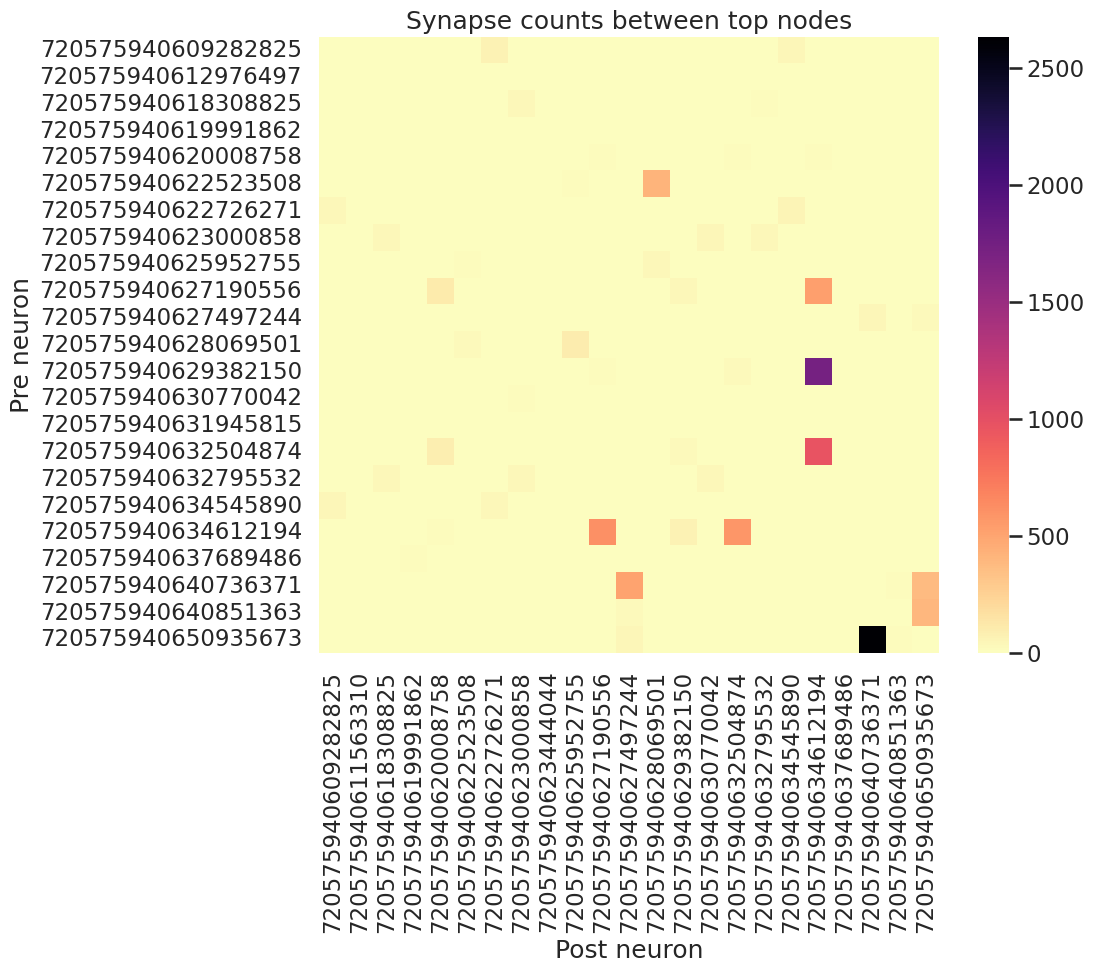

In [16]:
top_nodes = degree_df.sort_values('out_strength', ascending=False).head(30).index
subset = connections[connections['pre_root_id'].isin(top_nodes) & connections['post_root_id'].isin(top_nodes)]
pivot = subset.pivot_table(index='pre_root_id', columns='post_root_id', values='syn_count', fill_value=0)
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, cmap='magma_r')
plt.title('Synapse counts between top nodes')
plt.xlabel('Post neuron')
plt.ylabel('Pre neuron');
plt.show()


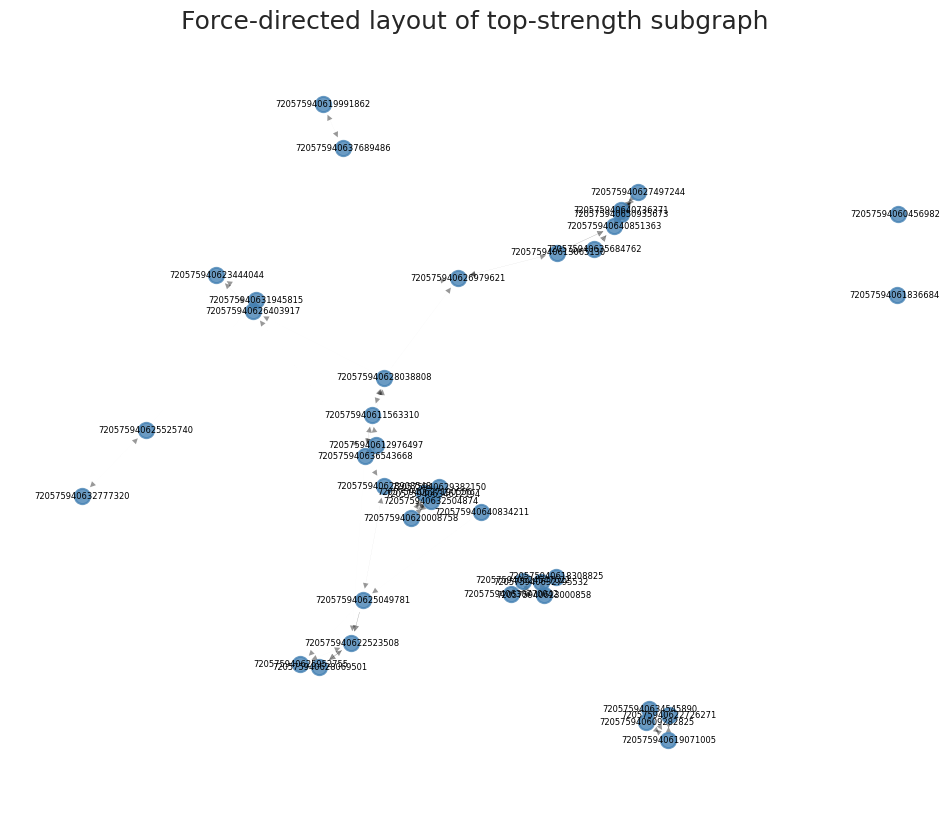

In [17]:
sub_nodes = degree_df.sort_values('out_strength', ascending=False).head(40).index
subG = G.subgraph(sub_nodes).copy()
pos = nx.spring_layout(subG, weight='syn_count', seed=42, k=0.5)
edge_weights = [subG[u][v]['syn_count'] for u, v in subG.edges()]
edge_norm = np.array(edge_weights) / np.max(edge_weights) if edge_weights else []
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(subG, pos, node_size=120, node_color='steelblue', alpha=0.8)
nx.draw_networkx_edges(subG, pos, width=2 * edge_norm if len(edge_norm) else 1, alpha=0.4)
nx.draw_networkx_labels(subG, pos, labels={n: n for n in sub_nodes}, font_size=6)
plt.title('Force-directed layout of top-strength subgraph')
plt.axis('off');
plt.show()


In [18]:
if HAS_PLOTLY:
    sample_nodes = degree_df.sort_values('out_strength', ascending=False).head(50).index
    sub = G.subgraph(sample_nodes).copy()
    pos = nx.spring_layout(sub, seed=7, weight='syn_count', k=0.6)

    edge_x, edge_y = [], []
    for u, v in sub.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y, line=dict(width=1, color='#888'), hoverinfo='none', mode='lines'
    )

    node_x, node_y, node_text, node_size = [], [], [], []
    for n in sub.nodes():
        x, y = pos[n]
        node_x.append(x)
        node_y.append(y)
        label = nodes.loc[n]['label'] if n in nodes.index else ''
        name = nodes.loc[n]['flywire_name'] if n in nodes.index else ''
        node_text.append(f"{n}<br>{label}<br>{name}")
        node_size.append(6 + np.log1p(degree_df.loc[n, 'out_strength']))

    node_trace = go.Scatter(
        x=node_x, y=node_y, mode='markers', hoverinfo='text', text=node_text,
        marker=dict(showscale=False, color='cornflowerblue', size=node_size, line_width=0.5)
    )

    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_layout(
        title='Interactive subgraph (top 50 by outgoing strength)',
        showlegend=False,
        hovermode='closest',
        margin=dict(l=10, r=10, b=10, t=40)
    )
    fig.show()
else:
    print('Plotly not available; install plotly for an interactive network view.')


## Optional: load precomputed centralities (if present)

In [20]:
centrality_path = Path('../data/preprocessed/node_centralities.csv')
if centrality_path.exists():
    centrality = pd.read_csv(centrality_path)
    display(centrality.head())
else:
    print('No precomputed centrality file found; skip.')


,id,name,degree_centrality,closeness,betweenness,eigenvector,pagerank
0,720575940603464672,AL.LH.7,0.103103,0.293342,0.012181,0.000071,0.000821
1,720575940605758142,AL.14,0.178178,0.301209,0.001826,0.000239,0.001955
2,720575940606722249,AL.45,0.182182,0.311880,0.000995,0.000171,0.001816
3,720575940609282825,AL.3,0.174174,0.316323,0.022744,0.000224,0.001811
4,720575940610161091,AL.80,0.175175,0.305828,0.000033,0.000135,0.001672


## Notes and next steps
- Adjust the `top_nodes`/`sample_nodes` thresholds if you want larger or smaller subgraphs.
- Replace the `nx.spring_layout` seed to explore different embeddings.
- Export subgraphs to tools like Gephi by writing `nx.readwrite.gexf.write_gexf(subG, 'subgraph.gexf')`.
- Consider normalizing `syn_count` by total outgoing synapses per neuron to get proportional connectivity.
- Use community detection (`nx.algorithms.community`) on `G` or its undirected version for mesoscale structure.